# Esplorazione del dataset KANDY

In questo notebook andiamo ad analizzare il dataset kandy-easy al fine di comprenderlo al meglio
prima di utilizzarlo negli esperimenti successivi, in particolare andiamo a osservare:

- struttura del dataset;
- distribuzione delle task;
- bilanciamento delle etichette;
- esempi di immagini;
- annotazioni simboliche;
- concetti visivi;
- struttura delle task e delle relative regole.

## 1. Ambiente

In [11]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)


Python executable: /home/cosimo/Downloads/kandy-xai/.venv/bin/python
Python version: 3.11.9 (main, Aug  7 2026, 13:00:06) [GCC 16.1.1 20260728]


## 2. Import e percorsi

In [12]:
from pathlib import Path
#mi permette di gestire più agilmente i percorsi
from collections import Counter
#mi permette di contare quante volte un elemento compare in una sequenza
import ast
#permette di trasformate una stringa di dati in una struttura dati di python
#es.: "[1,2,3]" -> [1, 2, 3]
import pandas as pd
#pandas per gestione dati tabellari
import matplotlib.pyplot as plt
#matplotlib per grafici
from PIL import Image
#pillow per lavorare con le immagini


PROJECT_ROOT = Path.cwd().parent
#ottengo la cartella di lavoro corrente

DATA_DIR = PROJECT_ROOT / "data" / "samples" / "sets"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

TRAIN_CSV = TRAIN_DIR / "annotations.csv"
VAL_CSV = VAL_DIR / "annotations.csv"
TEST_CSV = TEST_DIR / "annotations.csv"
#creo i vari percorsi/file in cui salvare i risultati

RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "dataset_exploration"
PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
#crea la cartella in cui salviamo tutti i risultati del notebook

print("Project root:", PROJECT_ROOT)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)


Project root: /home/cosimo/Downloads/kandy-xai
Train directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/train
Validation directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/val
Test directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/test


## 3. Caricamento delle annotazioni

In [13]:
df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)
#estraiamo i contenuti dai csv del dataset

print("Train samples:", len(df_train))
print("Validation samples:", len(df_val))
print("Test samples:", len(df_test))
#verifichiamo la grandezza del dataset

df_train.head()
#mostriamo i primi esempi del dataset di training

Train samples: 1000
Validation samples: 500
Test samples: 500


,filename,task_id,label,supervised,symbol
0,0/0000.png,0,1,1,"{'quadrant_lr': [{'shape': 'triangle', 'color'..."
1,0/0001.png,0,0,1,"{'quadrant_lr': [{'shape': 'circle', 'color': ..."
2,0/0002.png,0,0,1,"{'quadrant_ur': [{'shape': 'circle', 'color': ..."
3,0/0003.png,0,1,1,"{'quadrant_ll': [{'shape': 'triangle', 'color'..."
4,0/0004.png,0,0,1,"{'quadrant_ul': [{'shape': 'circle', 'color': ..."


In [14]:
df_train.info()
#andiamo a osservare alcune caratteristiche riassuntive sul dataset di training

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    1000 non-null   str  
 1   task_id     1000 non-null   int64
 2   label       1000 non-null   int64
 3   supervised  1000 non-null   int64
 4   symbol      1000 non-null   str  
dtypes: int64(3), str(2)
memory usage: 39.2 KB


### Campi delle annotazioni

- `filename`: percorso relativo dell’immagine;
- `task_id`: identificatore della task KANDY;
- `label`: etichetta binaria;
- `supervised`: indicatore di supervisione;
- `symbol`: descrizione simbolica della scena.

## 4. Statistiche del dataset

In [15]:
n_tasks = df_train["task_id"].nunique()
print("Number of tasks:", n_tasks)
#andiamo a contare quanti task differenti abbiamo

print("Training samples:", len(df_train))

print("\nSamples per task:")
print(df_train["task_id"].value_counts().sort_index())
#contiamo quanti esempi per task abbiamo e li ordiniamo per numero di valori

n_tasks = df_val["task_id"].nunique()
print("Number of tasks:", n_tasks)
#andiamo a contare quanti task differenti abbiamo

print("Validation samples:", len(df_val))

print("\nSamples per task:")
print(df_val["task_id"].value_counts().sort_index())
#contiamo quanti esempi per task abbiamo e li ordiniamo per numero di valori

n_tasks = df_test["task_id"].nunique()
print("Number of tasks:", n_tasks)
#andiamo a contare quanti task differenti abbiamo

print("Test samples:", len(df_test))

print("\nSamples per task:")
print(df_test["task_id"].value_counts().sort_index())
#contiamo quanti esempi per task abbiamo e li ordiniamo per numero di valori

Number of tasks: 20
Training samples: 1000

Samples per task:
task_id
0     50
1     50
2     50
3     50
4     50
5     50
6     50
7     50
8     50
9     50
10    50
11    50
12    50
13    50
14    50
15    50
16    50
17    50
18    50
19    50
Name: count, dtype: int64
Number of tasks: 20
Validation samples: 500

Samples per task:
task_id
0     25
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    25
12    25
13    25
14    25
15    25
16    25
17    25
18    25
19    25
Name: count, dtype: int64
Number of tasks: 20
Test samples: 500

Samples per task:
task_id
0     25
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    25
12    25
13    25
14    25
15    25
16    25
17    25
18    25
19    25
Name: count, dtype: int64


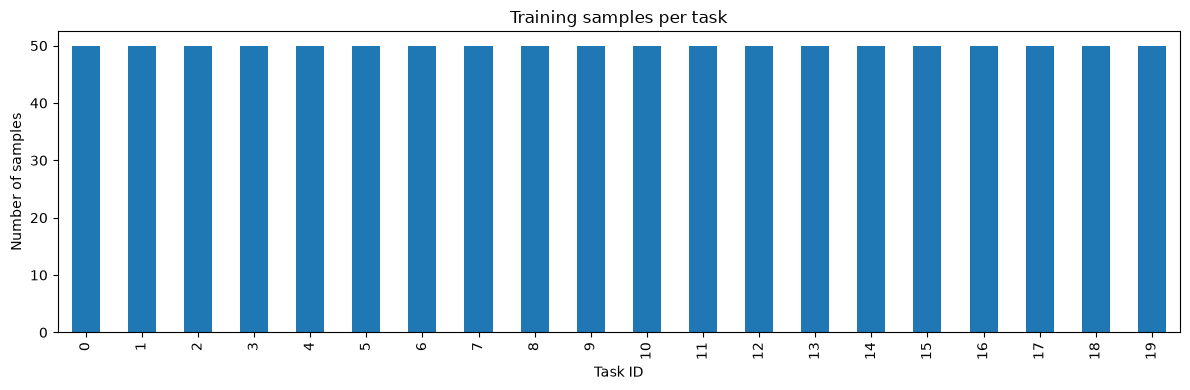

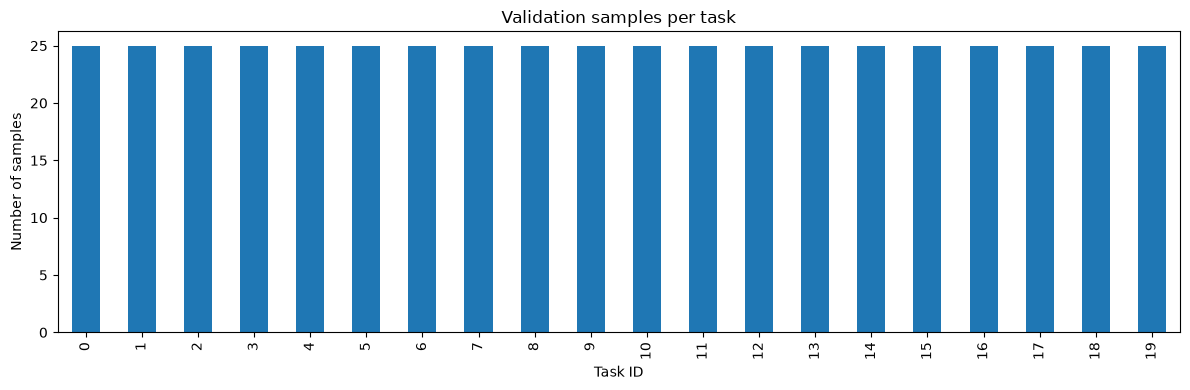

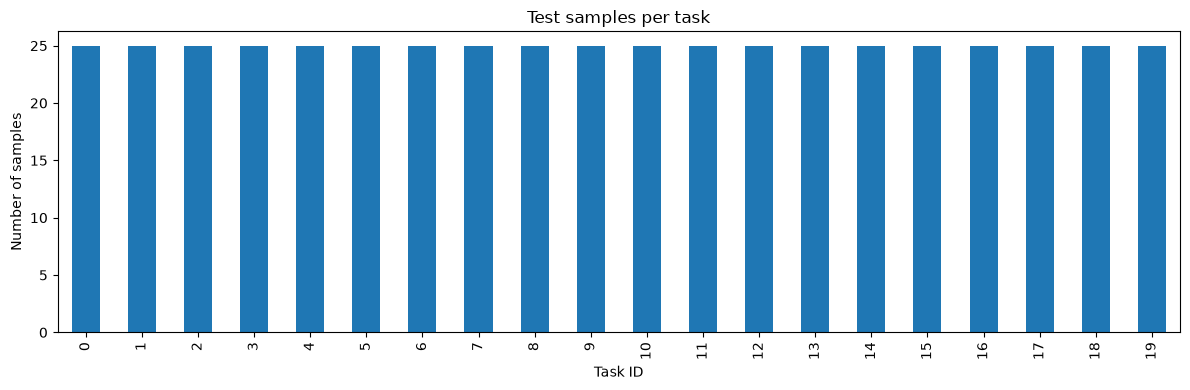

In [32]:
task_distribution = (
    df_train["task_id"]
    .value_counts()
    .sort_index()
)

ax = task_distribution.plot(
    kind="bar",
    figsize=(12, 4),
    title="Training samples per task",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "task_distribution_train.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del training set

plt.show()
plt.close()

#andiamo a plottare la distribuzione del training set:
#tutti i task hanno lo stesso numero di esempi


task_distribution = (
    df_val["task_id"]
    .value_counts()
    .sort_index()
)

ax = task_distribution.plot(
    kind="bar",
    figsize=(12, 4),
    title="Validation samples per task",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "task_distribution_val.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del validation set

plt.show()
plt.close()


task_distribution = (
    df_test["task_id"]
    .value_counts()
    .sort_index()
)

ax = task_distribution.plot(
    kind="bar",
    figsize=(12, 4),
    title="Test samples per task",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "task_distribution_test.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del test set

plt.show()
plt.close()

## 5. Distribuzione delle etichette

In [17]:
label_distribution_train = df_train["label"].value_counts().sort_index()
print(label_distribution_train)

label_distribution_val = df_val["label"].value_counts().sort_index()
print(label_distribution_val)

label_distribution_test = df_test["label"].value_counts().sort_index()
print(label_distribution_test)

      
#andiamo a vedere come sono distribuite le label, cioè quanti esempi positivi e negativi abbiamo per ciascuna classe

label
0    594
1    406
Name: count, dtype: int64
label
0    271
1    229
Name: count, dtype: int64
label
0    294
1    206
Name: count, dtype: int64


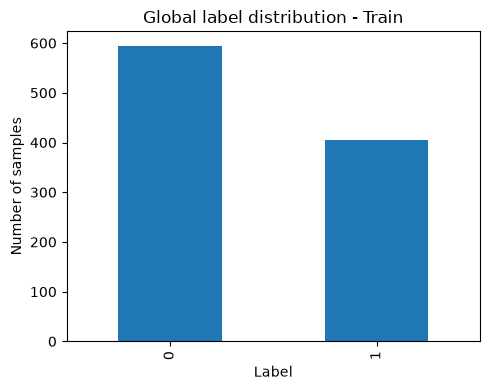

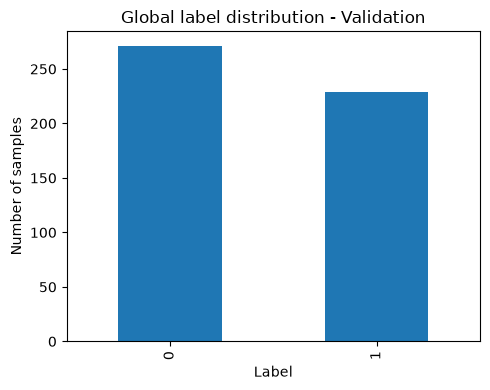

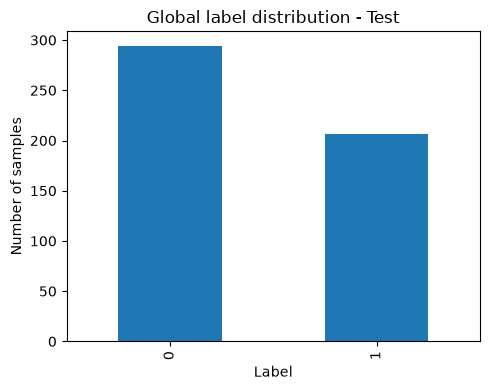

In [33]:
ax = label_distribution_train.plot(
    kind="bar",
    figsize=(5, 4),
    title="Global label distribution - Train",
)
ax.set_xlabel("Label")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "label_distribution_train.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del training set

plt.show()
plt.close()

#andiamo a plottare la distribuzione della label e notiamo che ci sono
#più esempi negativi (ciò che non è)
#che esempi positivi (ciò che è)


ax = label_distribution_val.plot(
    kind="bar",
    figsize=(5, 4),
    title="Global label distribution - Validation",
)
ax.set_xlabel("Label")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "label_distribution_val.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del validation set

plt.show()
plt.close()


ax = label_distribution_test.plot(
    kind="bar",
    figsize=(5, 4),
    title="Global label distribution - Test",
)
ax.set_xlabel("Label")
ax.set_ylabel("Number of samples")
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "label_distribution_test.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del test set

plt.show()
plt.close()

In [19]:
majority_baseline = df_train["label"].value_counts(normalize=True).max()
print(f"Majority baseline accuracy: {majority_baseline:.2%}")
#andiamo ora a contare gli esempi per classe in percentuale ed estraiamo la percentuale più ampia,
#in particolare, c'interesserà che il nostro modello superi questa percentuale di accuracy
#e non che classifiche semplicemente tutto il dataset come la classe maggioritaria

Majority baseline accuracy: 59.40%


## 6. Distribuzione delle etichette per task

In [20]:
task_labels_train = (
    df_train.groupby("task_id")["label"]
    .agg(total="count", positives="sum")
)
#raggruppo il dataset per task_id e vado a contare le label per ciascun task (50 per task come avevamo visto prima)
#e aggiungo due colonne 

task_labels_train["negatives"] = task_labels_train["total"] - task_labels_train["positives"]
task_labels_train["positive_ratio"] = task_labels_train["positives"] / task_labels_train["total"]
#vado a calcolare n_label_positive, n_label_negative e il rapporto tra esempi positivi ed esempi totali

print(task_labels_train)
#si noti che su quasi tutti i casi il numero di esempi positivi è strettamente minore di quelli negativi,
#nel task 19 (semaforo), abbiamo che solo il 10% degli esempi è positivo

task_labels_val = (
    df_val.groupby("task_id")["label"]
    .agg(total="count", positives="sum")
) 

task_labels_val["negatives"] = task_labels_val["total"] - task_labels_val["positives"]
task_labels_val["positive_ratio"] = task_labels_val["positives"] / task_labels_val["total"]

print(task_labels_val)


task_labels_test = (
    df_test.groupby("task_id")["label"]
    .agg(total="count", positives="sum")
)

task_labels_test["negatives"] = task_labels_test["total"] - task_labels_test["positives"]
task_labels_test["positive_ratio"] = task_labels_test["positives"] / task_labels_test["total"]

print(task_labels_test)

         total  positives  negatives  positive_ratio
task_id                                             
0           50         20         30            0.40
1           50         20         30            0.40
2           50         28         22            0.56
3           50         13         37            0.26
4           50         13         37            0.26
5           50         11         39            0.22
6           50         11         39            0.22
7           50         14         36            0.28
8           50         15         35            0.30
9           50         21         29            0.42
10          50         30         20            0.60
11          50         30         20            0.60
12          50         23         27            0.46
13          50         29         21            0.58
14          50         30         20            0.60
15          50         27         23            0.54
16          50         20         30          

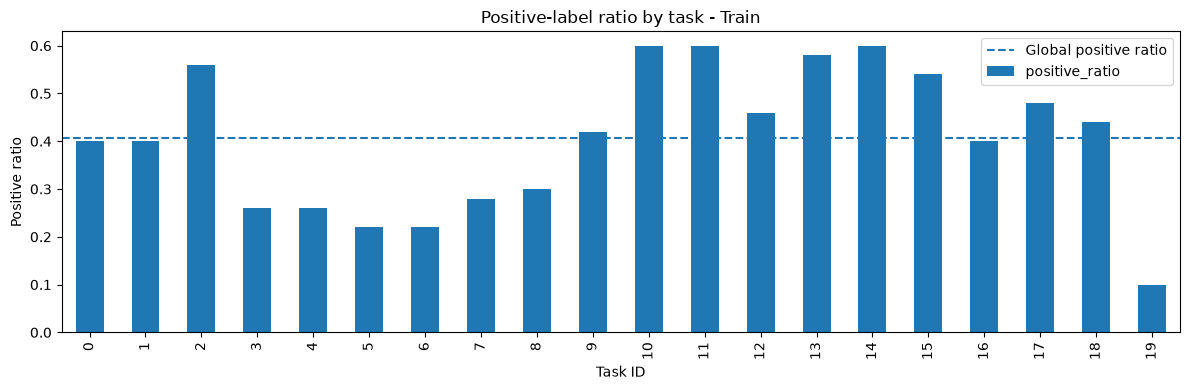

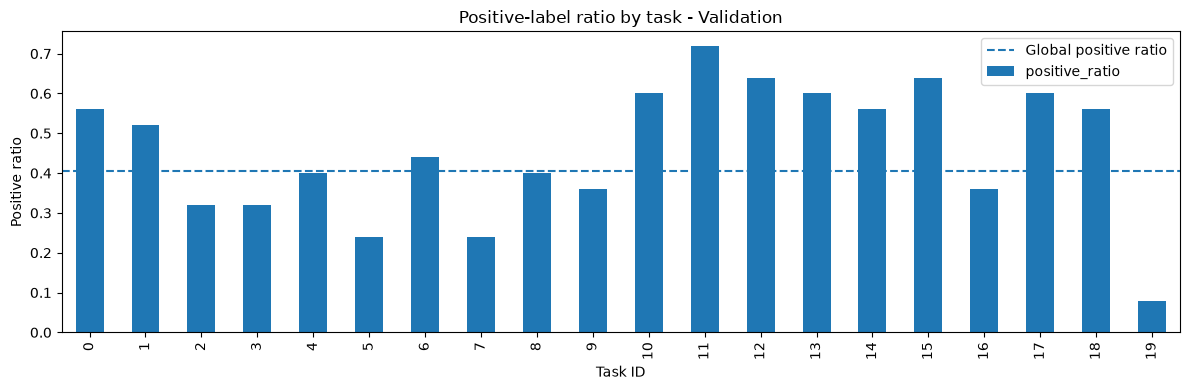

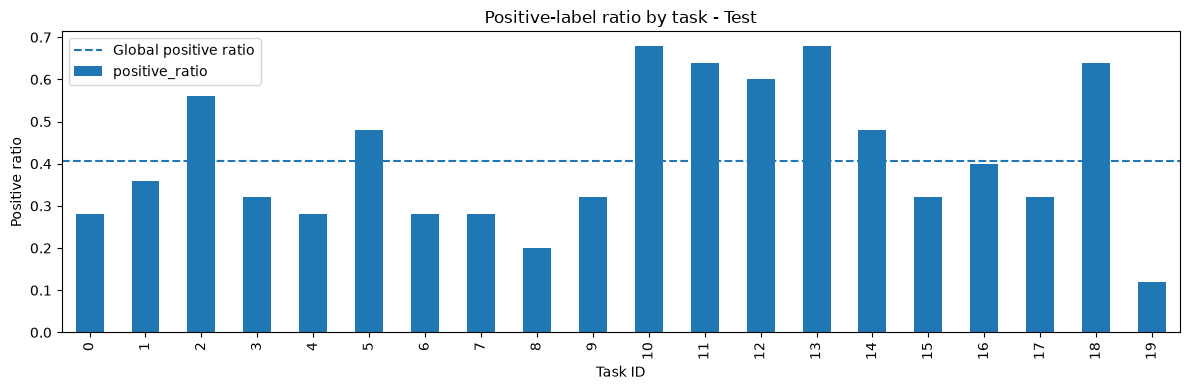

In [34]:
ax = task_labels_train["positive_ratio"].plot(
    kind="bar",
    figsize=(12, 4),
    title="Positive-label ratio by task - Train",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Positive ratio")

plt.axhline(
    df_train["label"].mean(),
    linestyle="--",
    label="Global positive ratio",
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "positive_ratio_train.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del training set

plt.show()
plt.close()

#andiamo a visualizzare il risultato.
#siccome la distribuzione degli esempi positivi tra i vari task varia,
#ed è spesso sbilanciata, dovremo utilizzare anche metriche diverse
#per valutare i modelli:
#precision, recall, F1


ax = task_labels_val["positive_ratio"].plot(
    kind="bar",
    figsize=(12, 4),
    title="Positive-label ratio by task - Validation",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Positive ratio")

plt.axhline(
    df_train["label"].mean(),
    linestyle="--",
    label="Global positive ratio",
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "positive_ratio_val.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del validation set

plt.show()
plt.close()


ax = task_labels_test["positive_ratio"].plot(
    kind="bar",
    figsize=(12, 4),
    title="Positive-label ratio by task - Test",
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Positive ratio")

plt.axhline(
    df_train["label"].mean(),
    linestyle="--",
    label="Global positive ratio",
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "positive_ratio_test.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del test set

plt.show()
plt.close()

## 7. Parsing delle annotazioni simboliche

In [22]:
df_train["symbol_parsed"] = df_train["symbol"].apply(ast.literal_eval)
df_val["symbol_parsed"] = df_val["symbol"].apply(ast.literal_eval)
df_test["symbol_parsed"] = df_test["symbol"].apply(ast.literal_eval)
#nel dataset gli esempi sono costruiti a partire dal "symbol" ovvero:
#si hanno delle stringhe in un file yaml e tramite un generatore:
#
#qui andiamo a utilizzare ast per trasformare ciascuna stringa
#dizionario python, questo ci servirà per estrarre alcune
#statistiche importanti dai dati, in particolare:
#quante volte un certo concetto è stato utilizzato.

df_train[["filename", "task_id", "label", "symbol", "symbol_parsed"]].head()


,filename,task_id,label,symbol,symbol_parsed
0,0/0000.png,0,1,"{'quadrant_lr': [{'shape': 'triangle', 'color'...","{'quadrant_lr': [{'shape': 'triangle', 'color'..."
1,0/0001.png,0,0,"{'quadrant_lr': [{'shape': 'circle', 'color': ...","{'quadrant_lr': [{'shape': 'circle', 'color': ..."
2,0/0002.png,0,0,"{'quadrant_ur': [{'shape': 'circle', 'color': ...","{'quadrant_ur': [{'shape': 'circle', 'color': ..."
3,0/0003.png,0,1,"{'quadrant_ll': [{'shape': 'triangle', 'color'...","{'quadrant_ll': [{'shape': 'triangle', 'color'..."
4,0/0004.png,0,0,"{'quadrant_ul': [{'shape': 'circle', 'color': ...","{'quadrant_ul': [{'shape': 'circle', 'color': ..."


## 8. Analisi dei concetti simbolici

In [23]:
def iter_objects(symbol):
    for position, objects in symbol.items():
        for obj in objects:
            yield position, obj

#funzione "comoda" che ci servira' dopo,
#prendiamo la lista delle descrizioni simboliche e,
#ogni volta che chiamiamo la funzione, questa
#ci restituisce "on the fly" la coppia position, object successiva

structure_counter = Counter()

for symbol in df_train["symbol_parsed"]:
    for position, objects in symbol.items():
        for obj in objects:
            structure_counter[tuple(sorted(obj.keys()))] += 1


for symbol in df_val["symbol_parsed"]:
    for position, objects in symbol.items():
        for obj in objects:
            structure_counter[tuple(sorted(obj.keys()))] += 1


for symbol in df_test["symbol_parsed"]:
    for position, objects in symbol.items():
        for obj in objects:
            structure_counter[tuple(sorted(obj.keys()))] += 1
#qui contiamo quante volte compare ogni struttura di attributi
#negli oggetti presenti nelle descrizioni simboliche.

print("Different object structures found:")
for structure, count in structure_counter.items():
    print(f"{count:4d} -> {structure}")


Different object structures found:
2733 -> ('color', 'shape', 'size')
  12 -> ('grid',)
 315 -> ('stack',)
  14 -> ('stack_reduce_bb',)
  20 -> ('diag_ul_lr',)
  15 -> ('diag_ll_ur',)
  12 -> ('side_by_side_reduce_bb',)
 212 -> ('side_by_side',)


=======TRAINSET=======
Shape counts: {'triangle': 523, 'circle': 428, 'square': 417}
Color counts: {'blue': 236, 'cyan': 195, 'magenta': 193, 'yellow': 209, 'green': 207, 'red': 328}
Size counts: {'large': 676, 'small': 692}
Position counts: {'quadrant_lr': 130, 'quadrant_ur': 157, 'quadrant_ll': 150, 'quadrant_ul': 164, 'in': 149, 'side_by_side': 918}


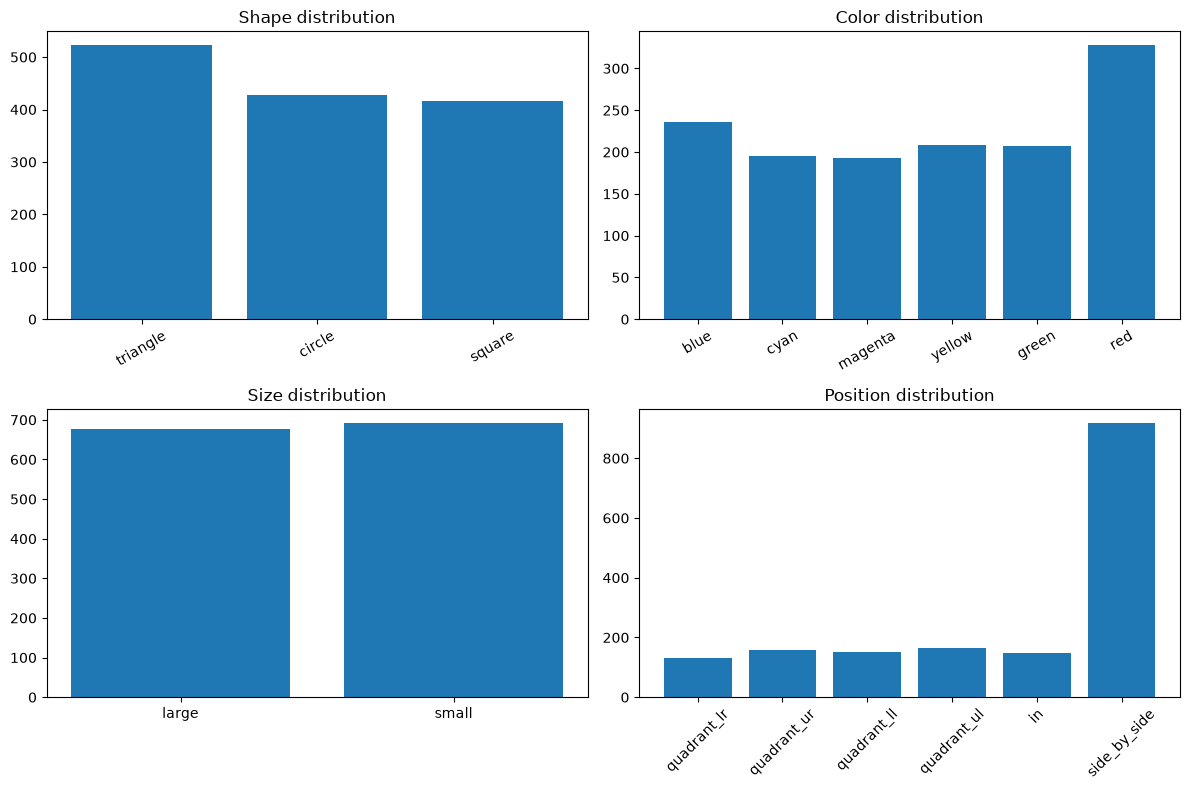

=======VALIDATIONSET=======
Shape counts: {'square': 204, 'triangle': 284, 'circle': 198}
Color counts: {'yellow': 107, 'green': 92, 'blue': 119, 'magenta': 96, 'red': 174, 'cyan': 98}
Size counts: {'small': 324, 'large': 362}
Position counts: {'quadrant_ul': 74, 'quadrant_ur': 69, 'quadrant_lr': 81, 'quadrant_ll': 83, 'in': 68, 'side_by_side': 461}


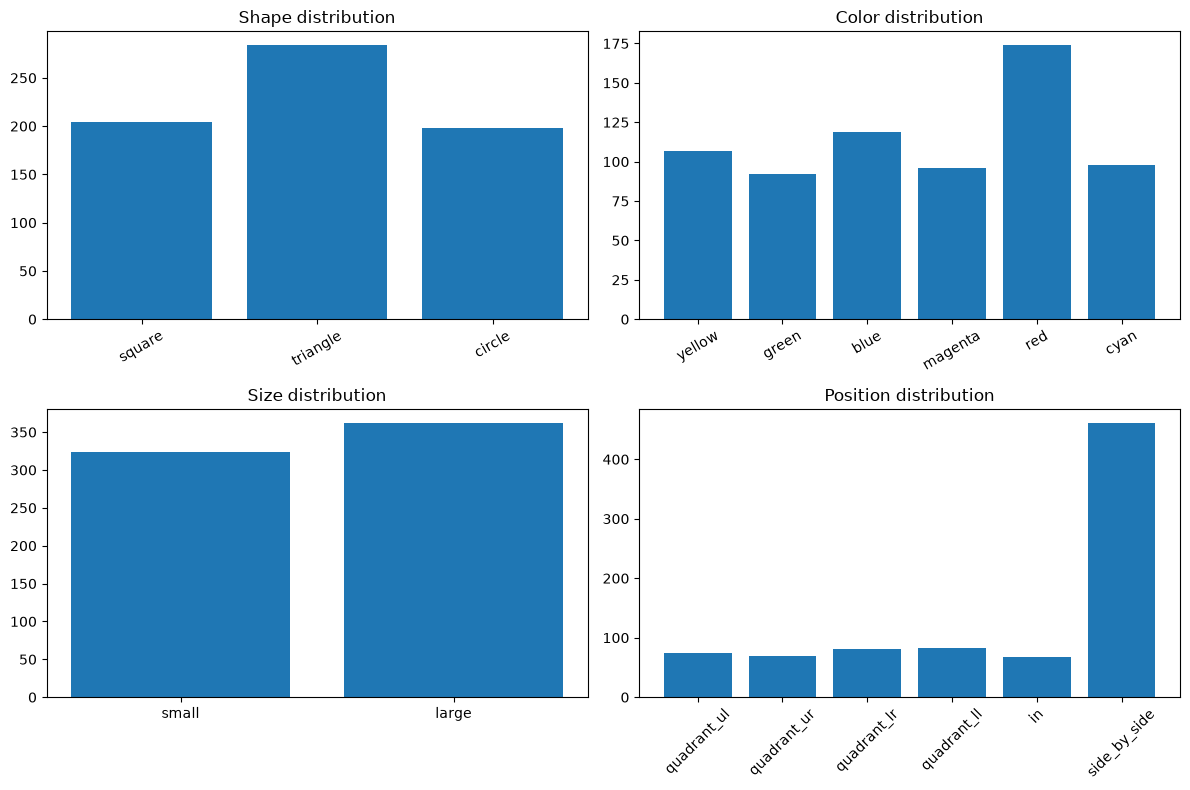

=======TESTSET=======
Shape counts: {'triangle': 259, 'circle': 235, 'square': 185}
Color counts: {'blue': 116, 'red': 177, 'cyan': 99, 'magenta': 97, 'yellow': 84, 'green': 106}
Size counts: {'large': 345, 'small': 334}
Position counts: {'quadrant_ul': 75, 'in': 72, 'quadrant_ur': 69, 'quadrant_lr': 80, 'quadrant_ll': 79, 'side_by_side': 454}


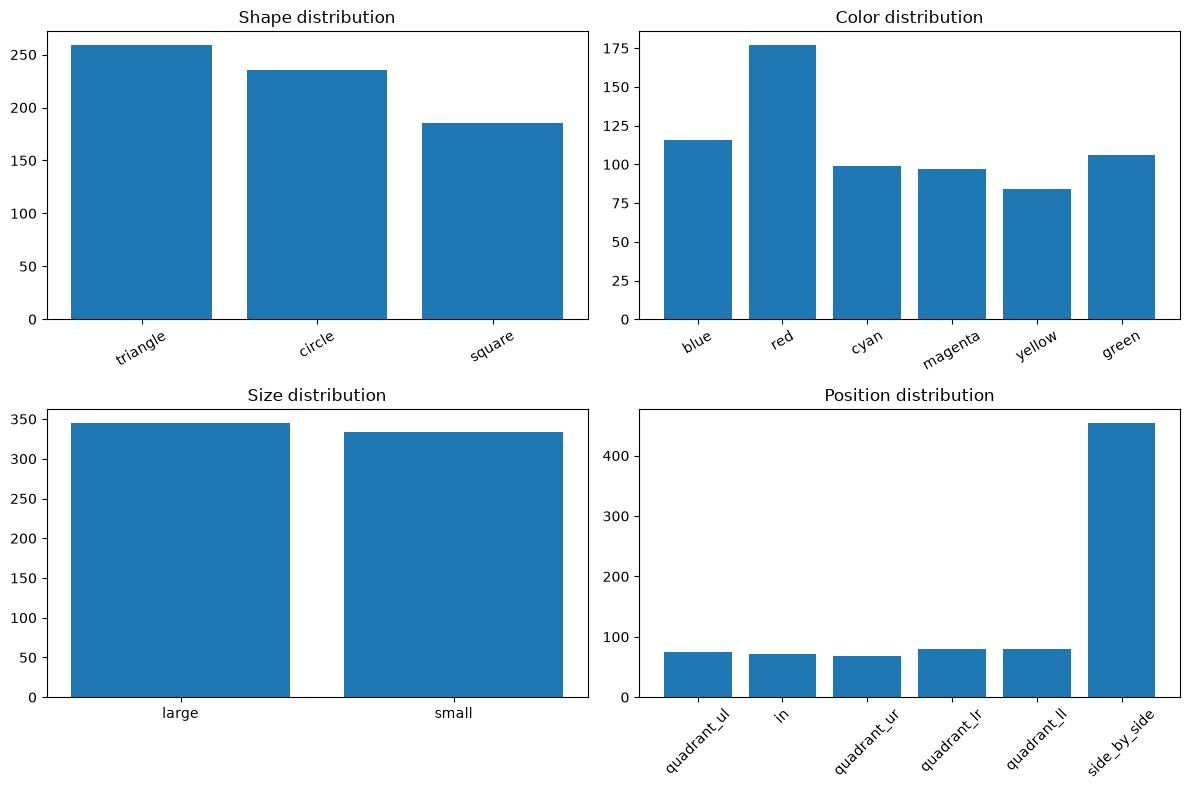

In [38]:
shape_counter = Counter()
color_counter = Counter()
size_counter = Counter()
position_counter = Counter()

for symbol in df_train["symbol_parsed"]:
    for position, obj in iter_objects(symbol):
        position_counter[position] += 1

        if "shape" in obj:
            shape_counter[obj["shape"]] += 1

        if "color" in obj:
            color_counter[obj["color"]] += 1

        if "size" in obj:
            size_counter[obj["size"]] += 1

#qui andiamo a estrarre tutte le descrizioni simboliche,
#dopodiché, utilizzando la funzione di prima, andiamo a
#estrarre uno a uno gli oggetti con la loro posizione

print("=======TRAINSET=======")
print("Shape counts:", dict(shape_counter))
print("Color counts:", dict(color_counter))
print("Size counts:", dict(size_counter))
print("Position counts:", dict(position_counter))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes[0, 0].bar(
    shape_counter.keys(),
    shape_counter.values(),
)
axes[0, 0].set_title("Shape distribution")
axes[0, 0].tick_params(
    axis="x",
    rotation=30,
)

axes[0, 1].bar(
    color_counter.keys(),
    color_counter.values(),
)
axes[0, 1].set_title("Color distribution")
axes[0, 1].tick_params(
    axis="x",
    rotation=30,
)

axes[1, 0].bar(
    size_counter.keys(),
    size_counter.values(),
)
axes[1, 0].set_title("Size distribution")

axes[1, 1].bar(
    position_counter.keys(),
    position_counter.values(),
)
axes[1, 1].set_title("Position distribution")
axes[1, 1].tick_params(
    axis="x",
    rotation=45,
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_properties_train.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del training set

plt.show()
plt.close(fig)

shape_counter = Counter()
color_counter = Counter()
size_counter = Counter()
position_counter = Counter()
#reset dei contatori prima di analizzare il validation set

for symbol in df_val["symbol_parsed"]:
    for position, obj in iter_objects(symbol):
        position_counter[position] += 1

        if "shape" in obj:
            shape_counter[obj["shape"]] += 1

        if "color" in obj:
            color_counter[obj["color"]] += 1

        if "size" in obj:
            size_counter[obj["size"]] += 1

print("=======VALIDATIONSET=======")
print("Shape counts:", dict(shape_counter))
print("Color counts:", dict(color_counter))
print("Size counts:", dict(size_counter))
print("Position counts:", dict(position_counter))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes[0, 0].bar(
    shape_counter.keys(),
    shape_counter.values(),
)
axes[0, 0].set_title("Shape distribution")
axes[0, 0].tick_params(
    axis="x",
    rotation=30,
)

axes[0, 1].bar(
    color_counter.keys(),
    color_counter.values(),
)
axes[0, 1].set_title("Color distribution")
axes[0, 1].tick_params(
    axis="x",
    rotation=30,
)

axes[1, 0].bar(
    size_counter.keys(),
    size_counter.values(),
)
axes[1, 0].set_title("Size distribution")

axes[1, 1].bar(
    position_counter.keys(),
    position_counter.values(),
)
axes[1, 1].set_title("Position distribution")
axes[1, 1].tick_params(
    axis="x",
    rotation=45,
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_properties_val.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del validation set

plt.show()
plt.close(fig)

shape_counter = Counter()
color_counter = Counter()
size_counter = Counter()
position_counter = Counter()
#reset dei contatori prima di analizzare il test set

for symbol in df_test["symbol_parsed"]:
    for position, obj in iter_objects(symbol):
        position_counter[position] += 1

        if "shape" in obj:
            shape_counter[obj["shape"]] += 1

        if "color" in obj:
            color_counter[obj["color"]] += 1

        if "size" in obj:
            size_counter[obj["size"]] += 1

print("=======TESTSET=======")
print("Shape counts:", dict(shape_counter))
print("Color counts:", dict(color_counter))
print("Size counts:", dict(size_counter))
print("Position counts:", dict(position_counter))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes[0, 0].bar(
    shape_counter.keys(),
    shape_counter.values(),
)
axes[0, 0].set_title("Shape distribution")
axes[0, 0].tick_params(
    axis="x",
    rotation=30,
)

axes[0, 1].bar(
    color_counter.keys(),
    color_counter.values(),
)
axes[0, 1].set_title("Color distribution")
axes[0, 1].tick_params(
    axis="x",
    rotation=30,
)

axes[1, 0].bar(
    size_counter.keys(),
    size_counter.values(),
)
axes[1, 0].set_title("Size distribution")

axes[1, 1].bar(
    position_counter.keys(),
    position_counter.values(),
)
axes[1, 1].set_title("Position distribution")
axes[1, 1].tick_params(
    axis="x",
    rotation=45,
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_properties_test.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del test set

plt.show()
plt.close(fig)

## 9. Numero di oggetti per immagine

In [25]:
def count_objects(symbol):
    return sum(len(objects) for objects in symbol.values())
#questa funzione ci permette di ottenere il numero totale di oggetti per descrizione simbolica

print("=======TRAINING=======")
df_train["num_objects"] = df_train["symbol_parsed"].apply(count_objects)
#andiamo a contare per ciascuna entrata
print(df_train["num_objects"].describe())
#otteniamo alcune statistiche: la maggior parte dei task ha 1 oggetto,
#il task col maggior numero ne ha 6

print("=======VAL=======")
df_val["num_objects"] = df_val["symbol_parsed"].apply(count_objects)
print(df_val["num_objects"].describe())

print("=======TEST=======")
df_test["num_objects"] = df_test["symbol_parsed"].apply(count_objects)
print(df_test["num_objects"].describe())

=======TRAINING=======
count    1000.000000
mean        1.668000
std         1.339989
min         1.000000
25%         1.000000
50%         1.000000
75%         1.250000
max         6.000000
Name: num_objects, dtype: float64
=======VAL=======
count    500.000000
mean       1.672000
std        1.352062
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max        6.000000
Name: num_objects, dtype: float64
=======TEST=======
count    500.000000
mean       1.658000
std        1.313196
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max        6.000000
Name: num_objects, dtype: float64


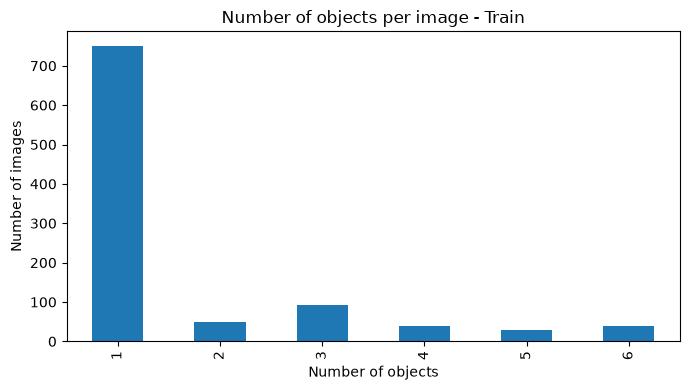

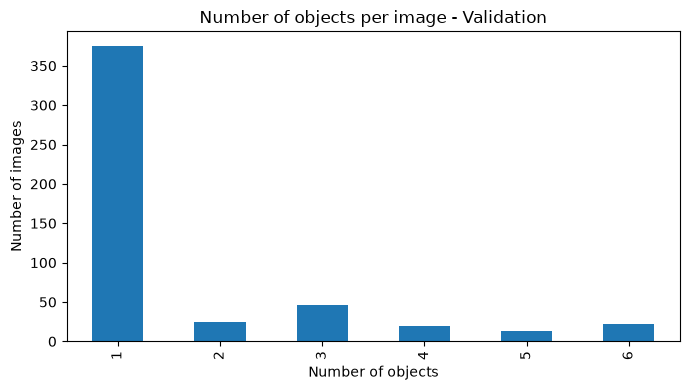

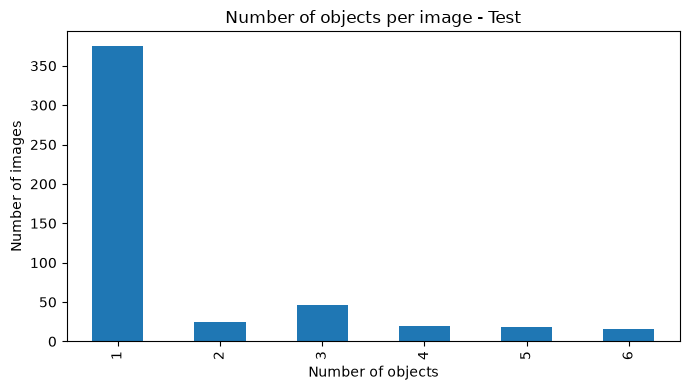

In [37]:
object_counts = (
    df_train["num_objects"]
    .value_counts()
    .sort_index()
)

ax = object_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Number of objects per image - Train",
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Number of images")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_count_train.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del training set

plt.show()
plt.close()


object_counts = (
    df_val["num_objects"]
    .value_counts()
    .sort_index()
)

ax = object_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Number of objects per image - Validation",
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Number of images")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_count_val.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del validation set

plt.show()
plt.close()


object_counts = (
    df_test["num_objects"]
    .value_counts()
    .sort_index()
)

ax = object_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Number of objects per image - Test",
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Number of images")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "object_count_test.png",
    dpi=200,
    bbox_inches="tight",
)
#salva il plot del test set

plt.show()
plt.close()

#la maggior parte degli esempi ha un solo oggetto.

## 10. Estrazione dei concetti interpretabili

In [27]:
def extract_concepts(symbol):
    objects = list(iter_objects(symbol))

    if not objects:
        return {
            "position": None,
            "shape": None,
            "color": None,
            "size": None,
            "num_objects": 0,
        }

    position, obj = objects[0]

    return {
        "position": position,
        "shape": obj.get("shape"),
        "color": obj.get("color"),
        "size": obj.get("size"),
        "num_objects": len(objects),
    }
#questa funzione serve per, data una descrizione simbolica ottenerne
#i concetti interpretabili, estrarne alcune proprietà
#interpretabili dell'oggetto e il numero totale di oggetti presenti.

concepts = df_train["symbol_parsed"].apply(extract_concepts)
#otteniamo dizionario concetti
concept_df = pd.DataFrame(concepts.tolist())
#li uniamo in una lista di dizionari, e facciamo diventare le chiavi dizionari
#delle colonne di un dataframe

df_concepts = pd.concat(
    [
        df_train[["filename", "task_id", "label"]].reset_index(drop=True),
        concept_df.reset_index(drop=True),
    ],
    axis=1,
)
#a questo affianchiamo le colonne ottenute dal dataframe, accanto a quelle originali.


df_concepts.head(200)


,filename,task_id,label,position,shape,color,size,num_objects
0,0/0000.png,0,1,quadrant_lr,triangle,blue,large,1
1,0/0001.png,0,0,quadrant_lr,circle,cyan,small,1
2,0/0002.png,0,0,quadrant_ur,circle,blue,small,1
3,0/0003.png,0,1,quadrant_ll,triangle,magenta,small,1
4,0/0004.png,0,0,quadrant_ul,circle,blue,large,1
...,...,...,...,...,...,...,...,...
195,3/0045.png,3,1,quadrant_lr,square,red,large,1
196,3/0046.png,3,0,quadrant_ul,circle,blue,large,1
197,3/0047.png,3,0,quadrant_ul,square,yellow,small,1
198,3/0048.png,3,0,quadrant_lr,square,magenta,small,1


Questi concetti forniscono le variabili interpretabili necessarie per confrontare in seguito il comportamento del modulo visivo con la descrizione simbolica della scena.

A livello concettuale, confronteremo:

`immagine -> encoder -> predizione`

con:

`immagine -> concetti -> classificatore -> predizione`


## 11. Visualizzazione delle immagini

Image path: /home/cosimo/Downloads/kandy-xai/data/samples/sets/train/0/0000.png
Image size: (224, 224)
Task: 0
Label: 1
Symbol: {'quadrant_lr': [{'shape': 'triangle', 'color': 'blue', 'size': 'large'}]}


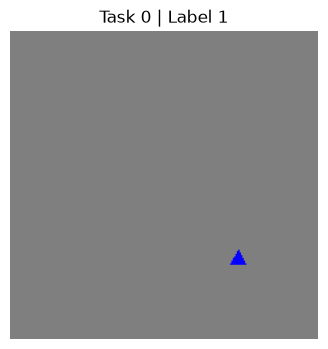

In [28]:
sample = df_train.iloc[0]
#accedo al dataframe di train e prendo la prima riga (prima immagine)

img_path = TRAIN_DIR / sample["filename"]
img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)
print("Task:", sample["task_id"])
print("Label:", sample["label"])
print("Symbol:", sample["symbol"])

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Task {sample.task_id} | Label {sample.label}")
plt.show()
#plottiamo task, label, concetti interpretabili contenuti nell'immagine e l'immagine

### Esempi positivi e negativi con descrizione

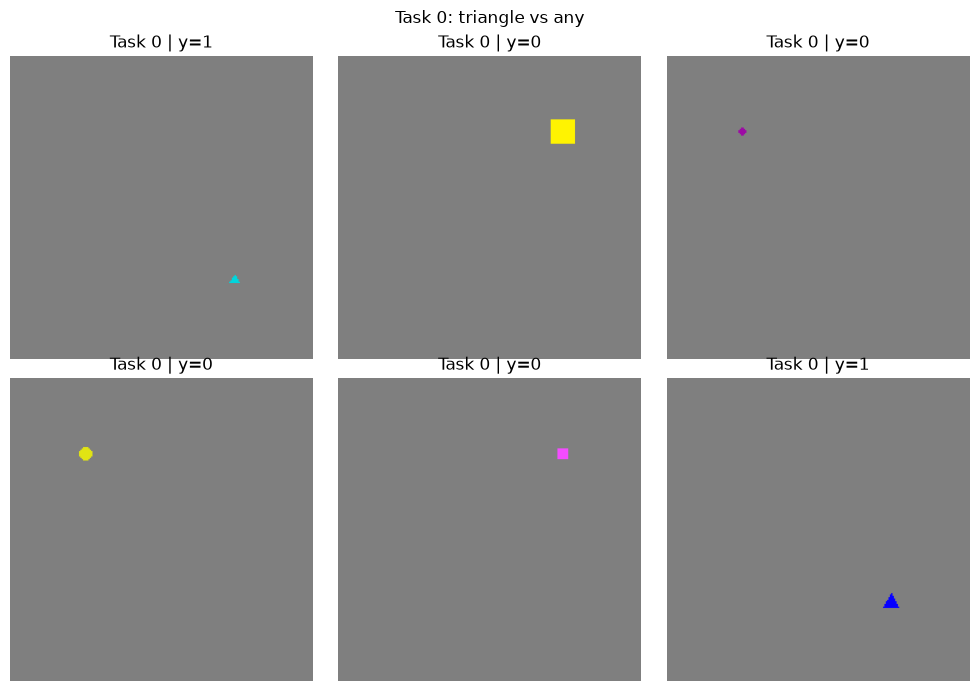

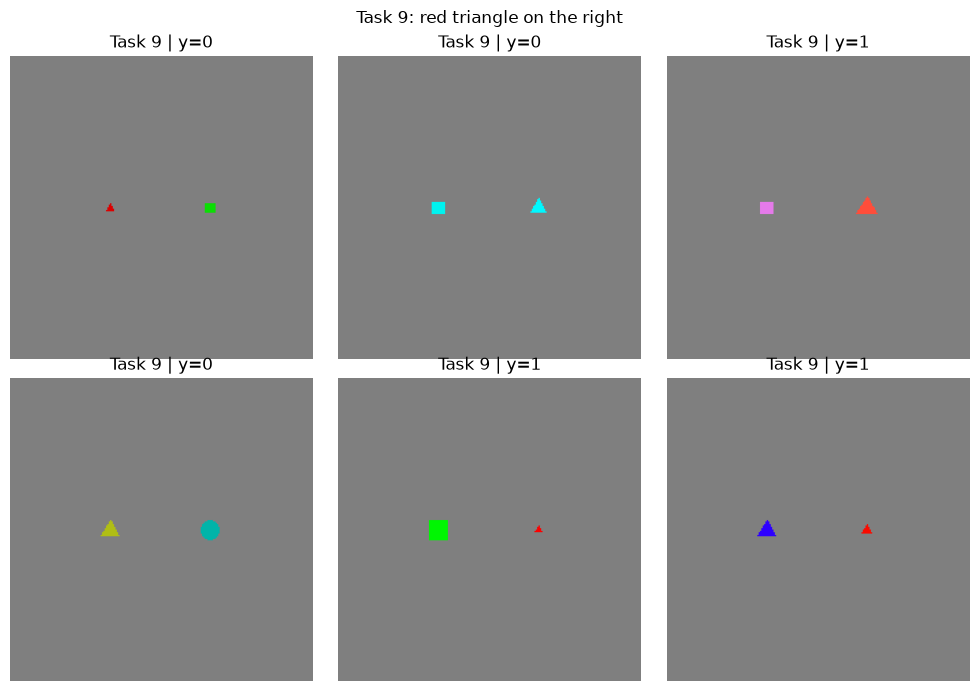

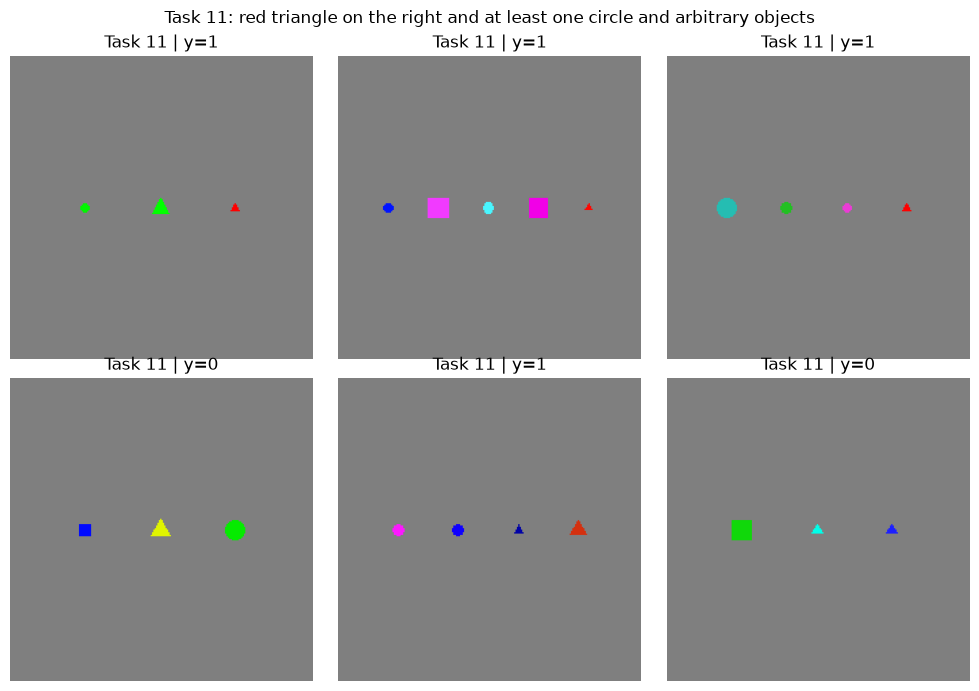

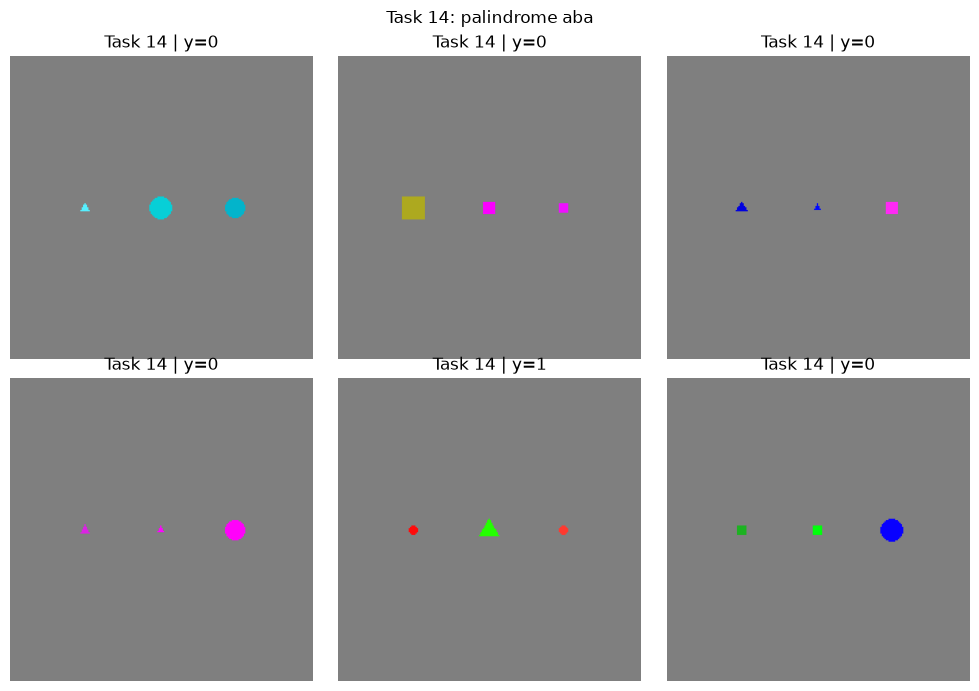

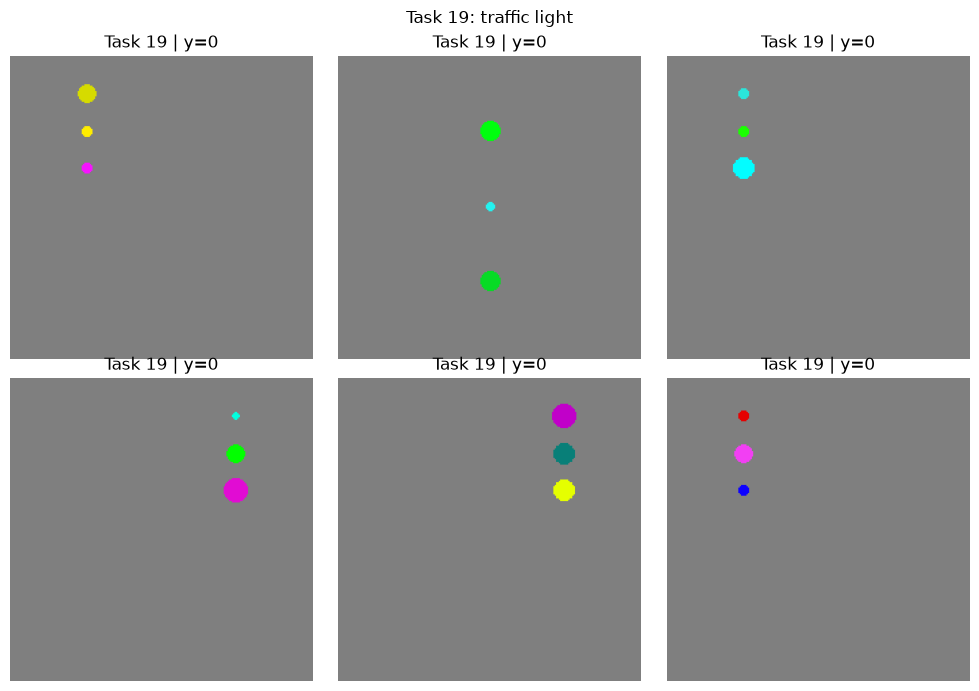

In [41]:
task_names = {
    0: "triangle vs any",
    1: "square vs any",
    2: "circle vs any",
    3: "red vs any",
    4: "green vs any",
    5: "blue vs any",
    6: "cyan vs any",
    7: "magenta vs any",
    8: "yellow vs any",
    9: "red triangle on the right",
    10: "red triangle on the right and arbitrary objects",
    11: "red triangle on the right and at least one circle and arbitrary objects",
    12: "red triangle on the right and at least one blue object and arbitrary objects",
    13: "triangle and square, same color",
    14: "palindrome aba",
    15: "house",
    16: "car",
    17: "tower",
    18: "wagon",
    19: "traffic light",
}

def show_task_examples(df, task_id, n=6, seed=123):
    subset = df[df["task_id"] == task_id]
    samples = subset.sample(n=min(n, len(subset)), random_state=seed)

    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = Image.open(TRAIN_DIR / row["filename"])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"Task {row.task_id} | y={row.label}")

    fig.suptitle(f"Task {task_id}: {task_names[task_id]}")
    plt.tight_layout()

    fig.savefig(
        PLOTS_DIR / f"task_{task_id}_examples.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)
    #salva l'immagine e chiude la figura

for task_id in [0, 9, 11, 14, 19]:
    show_task_examples(df_train, task_id)
#plottiamo e salviamo alcuni esempi per i task selezionati

## 12. Panoramica delle task

In [31]:
task_overview = task_labels_train.copy()
task_overview["task_name"] = task_overview.index.map(task_names)

task_overview[
    ["task_name", "total", "positives", "negatives", "positive_ratio"]
]

#piccolo riassunto finale.

,task_name,total,positives,negatives,positive_ratio
task_id,,,,,
0,triangle vs any,50,20,30,0.40
1,square vs any,50,20,30,0.40
2,circle vs any,50,28,22,0.56
3,red vs any,50,13,37,0.26
4,green vs any,50,13,37,0.26
5,blue vs any,50,11,39,0.22
6,cyan vs any,50,11,39,0.22
7,magenta vs any,50,14,36,0.28
8,yellow vs any,50,15,35,0.30


## 13. Conclusioni

Il dataset contiene dunque:

- 1000 immagini di training;
- 20 task di classificazione binaria;
- 50 campioni di training per task;
- annotazioni simboliche che descrivono le scene;
- concetti interpretabili come forma, colore, dimensione e posizione;
- regole logiche differenti tra le task.

La baseline globale ottenuta considerando il modello che predice la classe maggioritaria è circa 59,4%